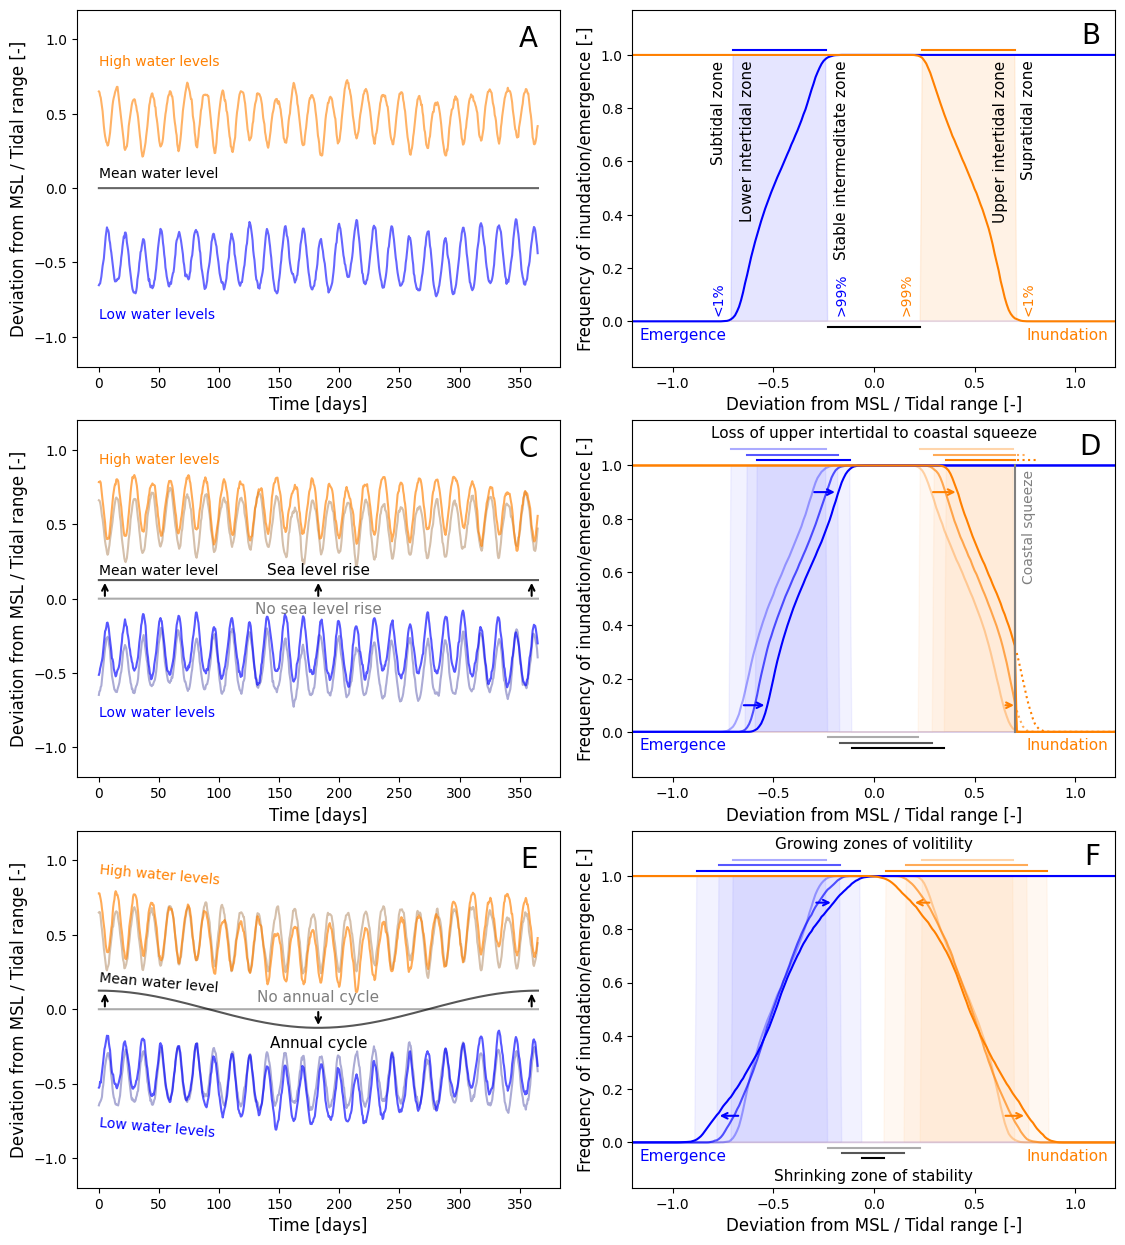

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

# path_root = "/Users/timhermans/Documents/GitHub/aslc_intertidal"
path_root = "F:/collaborations/Tim_Hermans/aslc_intertidal"
os.chdir(path_root)

import src.functions as f

def figure_1a(ax):

    time, waterlevel, mean_waterlevel = f.create_waterlevel_timeseries(amplitude_annual_cycle = 0., mean_waterlevel = 0., n_years = 1)

    tidal_cycle, low_waterlevel, high_waterlevel = f.calculate_highlow_water(waterlevel, plot = False)        
    ax.plot(time/24, mean_waterlevel, zorder = 1, color = [0,0,0,0.6])
    ax.plot(365*tidal_cycle/705, low_waterlevel, color = [0,0,1,0.6])
    # ax.plot(365*tidal_cycle/705, high_waterlevel, c = 'orange', alpha = 0.6)
    ax.plot(365*tidal_cycle/705, high_waterlevel, color = [1,0.5,0,0.6])

    ax.text(x = 0,     y =  0.85, s = 'High water levels', color = [1,0.5,0,1], fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center', rotation = 0)
    ax.text(x = 0,     y =  0.1, s = 'Mean water level',  color = [0,0,0,1],  fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center', rotation = 0)
    ax.text(x = 0,     y = -0.85, s = 'Low water levels',   color = [0,0,1,1],   fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center', rotation = 0)
    ax.text(x = 365, y = 1.1, s = 'A',  c = 'black',  fontsize = 20, horizontalalignment = 'right',   verticalalignment = 'top', rotation = 0)

    ax.set_ylabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
    ax.set_xlabel('Time [days]', fontsize = 12)
    ax.set_ylim(-1.2, 1.2)

def figure_1b(ax):

    dz = 0.01
    elevation = np.arange(-3, 3 + dz, dz)

    _, water_level, _ = f.create_waterlevel_timeseries(amplitude_annual_cycle = 0. , n_years = 10)
    _, low_waterlevel, high_waterlevel = f.calculate_highlow_water(water_level)
    emergence_freq, inundation_freq = f.calculate_inundation_metrics(elevation, low_waterlevel, high_waterlevel)
    
    intermediate_intertidal = (emergence_freq > 0.99) & (inundation_freq > 0.99)
    start_inter = elevation[np.where(intermediate_intertidal == 1)[0][0]]
    end_inter   = elevation[np.where(intermediate_intertidal == 1)[0][-1]]
    ax.plot([start_inter, end_inter], [-0.02,-0.02], color = [0,0,0,1])

    upper_intertidal = ((inundation_freq < 0.99) & (inundation_freq > 0.01))
    start_upper = elevation[np.where(upper_intertidal == 1)[0][0]]
    end_upper   = elevation[np.where(upper_intertidal == 1)[0][-1]]
    ax.plot([start_upper, end_upper], [1.02,1.02], color = [1,0.5,0,1])
    ax.fill_between(elevation, upper_intertidal, color = [1,0.5,0,0.1])

    lower_intertidal = ((emergence_freq < 0.99) & (emergence_freq > 0.01))
    start_lower = elevation[np.where(lower_intertidal == 1)[0][0]]
    end_lower   = elevation[np.where(lower_intertidal == 1)[0][-1]]
    ax.plot([start_lower, end_lower], [1.02,1.02], color = [0,0,1,1])
    ax.fill_between(elevation, lower_intertidal, color = [0,0,1,0.1])

    ax.text(  end_upper + 0.07, 0.98, rotation = 90, s = 'Supratidal zone', color = [0,0,0,1],  fontsize = 11, horizontalalignment = 'center', verticalalignment = 'top')
    ax.text(  end_upper - 0.07, 0.98, rotation = 90, s = 'Upper intertidal zone', color = [0,0,0,1],  fontsize = 11, horizontalalignment = 'center', verticalalignment = 'top')
    ax.text(start_inter + 0.07, 0.98, rotation = 90, s = 'Stable intermeditate zone', color = [0,0,0,1],  fontsize = 11, horizontalalignment = 'center', verticalalignment = 'top')
    ax.text(start_lower + 0.07, 0.98, rotation = 90, s = 'Lower intertidal zone', color = [0,0,0,1],  fontsize = 11, horizontalalignment = 'center', verticalalignment = 'top')
    ax.text(start_lower - 0.07, 0.98, rotation = 90, s = 'Subtidal zone', color = [0,0,0,1],  fontsize = 11, horizontalalignment = 'center', verticalalignment = 'top')

    ax.text(  end_upper + 0.07, 0.020, rotation = 90, s =  '<1%', color = [1,0.5,0,1], fontsize = 10, horizontalalignment = 'center',  verticalalignment = 'bottom')
    ax.text(  end_inter - 0.07, 0.020, rotation = 90, s = '>99%', color = [1,0.5,0,1], fontsize = 10, horizontalalignment = 'center',  verticalalignment = 'bottom')
    ax.text(start_inter + 0.07, 0.020, rotation = 90, s = '>99%', color = [0,0,1,1],   fontsize = 10, horizontalalignment = 'center',  verticalalignment = 'bottom')
    ax.text(start_lower - 0.07, 0.020, rotation = 90, s =  '<1%', color = [0,0,1,1],   fontsize = 10, horizontalalignment = 'center',  verticalalignment = 'bottom')

    ax.text( 2.33/2, -0.050, rotation = 0, s = 'Inundation', color = [1,0.5,0,1], fontsize = 11, horizontalalignment = 'right',  verticalalignment = 'center')
    ax.text(-2.33/2, -0.050, rotation = 0, s = 'Emergence', color = [0,0,1,1],   fontsize = 11, horizontalalignment = 'left',   verticalalignment = 'center')
    ax.text(x = 1.125, y = 1.125, s = 'B', color = [0,0,0,1],  fontsize = 20, horizontalalignment = 'right',   verticalalignment = 'top', rotation = 0)

    ax.plot(elevation, emergence_freq, color = [0,0,1,1])
    ax.plot(elevation, inundation_freq, color = [1,0.5,0,1])
    ax.set_ylabel('Frequency of inundation/emergence [-]', fontsize = 12)
    ax.set_xlabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
    ax.set_ylim(-0.17,1.17)
    ax.set_yticks(np.arange(0,1 + 0.2,0.2))
    ax.set_xlim(-2.4/2, 2.4/2)

def figure_1c(ax):

    def closest_to(seq, x):
        return np.argmin(np.abs(x - seq))
    
    time, waterlevel, mean_waterlevel_0 = f.create_waterlevel_timeseries(amplitude_annual_cycle = 0., mean_waterlevel = 0., n_years = 1)        
    tidal_cycle, low_waterlevel_0, high_waterlevel_0 = f.calculate_highlow_water(waterlevel, plot = False)    
    ax.plot(365*tidal_cycle/705, high_waterlevel_0, color = [0.5,0.25,0,0.33])
    ax.plot(time/24, mean_waterlevel_0, zorder = 1, color = [0,0,0,0.33])
    ax.plot(365*tidal_cycle/705, low_waterlevel_0, color = [0,0,0.5,0.33])

    time, waterlevel, mean_waterlevel_1 = f.create_waterlevel_timeseries(amplitude_annual_cycle = 0., mean_waterlevel = 0.25, n_years = 1)
    tidal_cycle, low_waterlevel_1, high_waterlevel_1 = f.calculate_highlow_water(waterlevel, plot = False)
    ax.plot(365*tidal_cycle/705, high_waterlevel_1, color = [1,0.5,0,0.66], label = 'High water levels')
    ax.plot(time/24, mean_waterlevel_1, zorder = 1, color = [0,0,0,0.66], label = 'Mean water level')
    ax.plot(365*tidal_cycle/705, low_waterlevel_1, color = [0,0,1,0.66], label = 'Low water levels')

    ax.annotate('', 
                xy = (5, mean_waterlevel_1[closest_to(time/24, 5)]), 
                xytext = (5, mean_waterlevel_0[closest_to(time/24, 5)]),
                arrowprops=dict(arrowstyle='->', color='black', lw = 1.5, alpha = 1))

    ax.annotate('', 
                xy = (365/2, mean_waterlevel_1[closest_to(time/24, 365/2)]), 
                xytext = (365/2, mean_waterlevel_0[closest_to(time/24, 365/2)]),
                arrowprops=dict(arrowstyle='->', color='black', lw = 1.5, alpha = 1))

    ax.annotate('', 
                xy = (360, mean_waterlevel_1[closest_to(time/24, 360)]), 
                xytext = (360, mean_waterlevel_0[closest_to(time/24, 360)]),
                arrowprops=dict(arrowstyle='->', color='black', lw = 1.5, alpha = 1))

    ax.text(x = 365/2, y = -0.07, s = 'No sea level rise',  color = [0,0,0,0.5], fontsize = 11, horizontalalignment = 'center', verticalalignment = 'center')
    ax.text(x = 365/2, y =  0.19, s = 'Sea level rise',  color = [0,0,0,1], fontsize = 11, horizontalalignment = 'center', verticalalignment = 'center')
    ax.text(x = 0,     y =  1.866/2, s = 'High water levels', color = [1,0.5,0,1], fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center', rotation = 0)
    ax.text(x = 0,     y =  0.19,     s = 'Mean water level',  color = [0,0,0,1], fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center', rotation = 0)
    ax.text(x = 0,     y = -1.533/2, s = 'Low water levels', color = [0,0,1,1], fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center', rotation = 0)
    ax.text(x = 365, y = 1.1, s = 'C',  c = 'black',  fontsize = 20, horizontalalignment = 'right',   verticalalignment = 'top', rotation = 0)

    ax.set_ylabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
    ax.set_xlabel('Time [days]', fontsize = 12)
    ax.set_ylim(-2.4/2, 2.4/2)

def figure_1d(ax):

    def closest_to(seq, x):
        return np.argmin(np.abs(x - seq))

    dz = 0.01
    elevation = np.arange(-3, 3 + dz, dz)

    # Run tidal water level scenarios
    _, water_level, _ = f.create_waterlevel_timeseries(mean_waterlevel = 0., n_years = 10)
    _, low_waterlevel, high_waterlevel = f.calculate_highlow_water(water_level)
    emergence_freq_0, inundation_freq_0 = f.calculate_inundation_metrics(elevation, low_waterlevel, high_waterlevel)

    _, water_level, _ = f.create_waterlevel_timeseries(mean_waterlevel = 0.125, n_years = 10)
    _, low_waterlevel, high_waterlevel = f.calculate_highlow_water(water_level)
    emergence_freq_1, inundation_freq_1 = f.calculate_inundation_metrics(elevation, low_waterlevel, high_waterlevel)

    _, water_level, _ = f.create_waterlevel_timeseries(mean_waterlevel = 0.25, n_years = 10)
    _, low_waterlevel, high_waterlevel = f.calculate_highlow_water(water_level)
    emergence_freq_2, inundation_freq_2 = f.calculate_inundation_metrics(elevation, low_waterlevel, high_waterlevel)

    # Modify output for tidal squeeze
    max_elevation = 0.7
    inundation_freq_1_squeeze   = np.where(elevation >  max_elevation, 0,      inundation_freq_1)
    inundation_freq_1_nosqueeze = np.where(elevation <= max_elevation, np.nan, inundation_freq_1)
    inundation_freq_2_squeeze   = np.where(elevation >  max_elevation, 0,      inundation_freq_2)
    inundation_freq_2_nosqueeze = np.where(elevation <= max_elevation, np.nan, inundation_freq_2)

    # Draw annotation bars of different intertidal zones
    def plot_daily_intertidal(elevation, emergence_freq, inundation_freq, alpha, ypos, linestyle = 'solid'):
        daily_intertidal = (emergence_freq > 0.99) & (inundation_freq > 0.99)
        start = elevation[np.where(daily_intertidal == 1)[0][0]]
        end   = elevation[np.where(daily_intertidal == 1)[0][-1]]
        ax.plot([start, end], [ypos,ypos], color = [0,0,0, alpha], linestyle = linestyle)

    def plot_intermitent_dry_intertidal(elevation, inundation_freq, alpha, ypos, linestyle = 'solid', fill = True):
        intermitent_dry_intertidal = ((inundation_freq < 0.99) & (inundation_freq > 0.01))
        start = elevation[np.where(intermitent_dry_intertidal == 1)[0][0]]
        end   = elevation[np.where(intermitent_dry_intertidal == 1)[0][-1]]
        if fill:
            ax.fill_between(elevation, intermitent_dry_intertidal, color = [1, 0.5, 0, 0.05])
        ax.plot([start, end], [ypos,ypos], color = [1, 0.5, 0, alpha], linestyle = linestyle)

    def plot_intermitent_wet_intertidal(elevation, emergence_freq, alpha, ypos, linestyle = 'solid', fill = True):
        intermitent_dry_intertidal = ((emergence_freq < 0.99) & (emergence_freq > 0.01))
        start = elevation[np.where(intermitent_dry_intertidal == 1)[0][0]]
        end   = elevation[np.where(intermitent_dry_intertidal == 1)[0][-1]]
        if fill:
            ax.fill_between(elevation, intermitent_dry_intertidal, color = [0,0,1,0.05])
        ax.plot([start, end], [ypos,ypos], color = [0,0,1,alpha], linestyle = linestyle)

    plot_daily_intertidal(elevation, emergence_freq_0, inundation_freq_0, alpha = 0.33, ypos = -0.02)
    plot_daily_intertidal(elevation, emergence_freq_1, inundation_freq_1, alpha = 0.66, ypos = -0.04)
    plot_daily_intertidal(elevation, emergence_freq_2, inundation_freq_2, alpha = 1.00, ypos = -0.06)

    plot_intermitent_wet_intertidal(elevation, emergence_freq_0, alpha = 0.33, ypos = 1.06)
    plot_intermitent_wet_intertidal(elevation, emergence_freq_1, alpha = 0.66, ypos = 1.04)
    plot_intermitent_wet_intertidal(elevation, emergence_freq_2, alpha = 1.00, ypos = 1.02)

    plot_intermitent_dry_intertidal(elevation, inundation_freq_0,           alpha = 0.33, ypos = 1.06)
    plot_intermitent_dry_intertidal(elevation, inundation_freq_1_squeeze,   alpha = 0.66, ypos = 1.04)
    plot_intermitent_dry_intertidal(elevation, inundation_freq_1_nosqueeze, alpha = 0.66, ypos = 1.04, linestyle = 'dotted', fill = False)
    plot_intermitent_dry_intertidal(elevation, inundation_freq_2_squeeze,   alpha = 1.00, ypos = 1.02)
    plot_intermitent_dry_intertidal(elevation, inundation_freq_2_nosqueeze, alpha = 1.00, ypos = 1.02, linestyle = 'dotted', fill = False)

    # Draw arrows            
    ax.annotate('', 
                xy =     (elevation[closest_to(inundation_freq_2_squeeze, 0.9)], 0.9), 
                xytext = (elevation[closest_to(inundation_freq_0, 0.9)], 0.9),
                arrowprops=dict(arrowstyle='->', color=[1,0.5,0,1], lw = 1.5))
    ax.annotate('', 
                xy =     (elevation[closest_to(inundation_freq_2_squeeze, 0.1)], 0.1), 
                xytext = (elevation[closest_to(inundation_freq_0, 0.1)], 0.1),
                arrowprops=dict(arrowstyle='->', color=[1,0.5,0,1], lw = 1.5))
    ax.annotate('', 
                xy =     (elevation[closest_to(emergence_freq_2, 0.9)], 0.9), 
                xytext = (elevation[closest_to(emergence_freq_0, 0.9)], 0.9),
                arrowprops=dict(arrowstyle='->', color = [0,0,1,1], lw = 1.5))
    ax.annotate('', 
                xy =     (elevation[closest_to(emergence_freq_2, 0.1)], 0.1), 
                xytext = (elevation[closest_to(emergence_freq_0, 0.1)], 0.1),
                arrowprops=dict(arrowstyle='->', color = [0,0,1,1], lw = 1.5))
    # Draw emergence/inundation frequency curves
    ax.plot(elevation, emergence_freq_0, color = [0,0,1,0.33])
    ax.plot(elevation, inundation_freq_0, color = [1,0.5,0,0.33])
    ax.plot(elevation, emergence_freq_1, color = [0,0,1,0.66])
    ax.plot(elevation, inundation_freq_1_squeeze, color = [1,0.5,0,0.66])
    ax.plot(elevation, inundation_freq_1_nosqueeze, color = [1,0.5,0,0.66], linestyle = 'dotted')
    ax.plot(elevation, emergence_freq_2, label = 'Frequency of emergence', color = [0,0,1,1])
    ax.plot(elevation, inundation_freq_2_squeeze, label = 'Frequency of inundation', color = [1,0.5,0,1])
    ax.plot(elevation, inundation_freq_2_nosqueeze, label = 'Frequency of inundation', color = [1,0.5,0,1], linestyle = 'dotted')

    # Draw text, axis labels, and define plot limits
    ax.plot([max_elevation, max_elevation], [0,1], c = 'grey', lw = 1.5)
    ax.text(x = max_elevation * 1.15, y = 0.77, s = 'Coastal squeeze', rotation = 90, color = [0.5,0.5,0.5,1], horizontalalignment = 'right', verticalalignment = 'center')
    ax.text(0,  1.12, rotation = 0, s = 'Loss of upper intertidal to coastal squeeze', color = [0,0,0,1],  fontsize = 11, horizontalalignment = 'center', verticalalignment = 'center')
    ax.text( 2.33/2, -0.05, rotation = 0, s = 'Inundation', color = [1,0.5,0,1], fontsize = 11, horizontalalignment = 'right', verticalalignment = 'center')
    ax.text(-2.33/2, -0.05, rotation = 0, s = 'Emergence', color = [0,0,1,1],   fontsize = 11, horizontalalignment = 'left', verticalalignment = 'center')
    ax.text(x = 1.125, y = 1.125, s = 'D', color = [0,0,0,1],  fontsize = 20, horizontalalignment = 'right',   verticalalignment = 'top', rotation = 0)
    ax.set_ylabel('Frequency of inundation/emergence [-]',    fontsize = 12)
    ax.set_xlabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
    ax.set_ylim(-0.17,1.17)
    ax.set_yticks(np.arange(0,1 + 0.2,0.2))
    ax.set_xlim(-2.4/2, 2.4/2)

def figure_1e(ax):

    def closest_to(seq, x):
        return np.argmin(np.abs(x - seq))
    
    time, waterlevel, mean_waterlevel = f.create_waterlevel_timeseries(amplitude_annual_cycle = 0., mean_waterlevel = 0., n_years = 1)
    tidal_cycle, low_waterlevel, high_waterlevel = f.calculate_highlow_water(waterlevel, plot = False)        
    ax.plot(time/24, mean_waterlevel, zorder = 1, color = [0,0,0,0.33])
    ax.plot(365*tidal_cycle/705, low_waterlevel, color = [0,0,0.5,0.33])
    ax.plot(365*tidal_cycle/705, high_waterlevel, color = [0.5,0.25,0,0.33])

    time, waterlevel, mean_waterlevel = f.create_waterlevel_timeseries(amplitude_annual_cycle = 0.25, mean_waterlevel = 0., n_years = 1)
    tidal_cycle, low_waterlevel, high_waterlevel = f.calculate_highlow_water(waterlevel, plot = False)
    ax.plot(365*tidal_cycle/705, high_waterlevel, color = [1,0.5,0,0.66], label = 'High water levels')
    ax.plot(time/24, mean_waterlevel, zorder = 1, color = [0,0,0,0.66], label = 'Mean water level')
    ax.plot(365*tidal_cycle/705, low_waterlevel, color = [0,0,1,0.66], label = 'Low water levels')

    ax.annotate('', 
                xy = (365/2, mean_waterlevel[closest_to(time/24, 365/2)]), 
                xytext = (365/2, 0),
                arrowprops=dict(arrowstyle='->', color = [0,0,0,1], lw = 1.5, alpha = 1))

    ax.annotate('', 
                xy = (5, mean_waterlevel[closest_to(time/24, 5)]), 
                xytext = (5, 0),
                arrowprops=dict(arrowstyle='->', color = [0,0,0,1], lw = 1.5, alpha = 1))

    ax.annotate('', 
                xy = (360, mean_waterlevel[closest_to(time/24, 360)]), 
                xytext = (360, 0),
                arrowprops=dict(arrowstyle='->', color = [0,0,0,0.66], lw = 1.5, alpha = 1))

    ax.text(x = 365/2, y =  0.166/2, s = 'No annual cycle',  color = [0,0,0,0.5], fontsize = 11, horizontalalignment = 'center', verticalalignment = 'center')
    ax.text(x = 365/2, y = -0.23, s = 'Annual cycle',     color = [0,0,0,1], fontsize = 11, horizontalalignment = 'center', verticalalignment = 'center')
    ax.text(x = 0,     y =  1.800/2, s = 'High water levels', color = [1,0.5,0,1], fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center', rotation = -5)
    ax.text(x = 0,     y =  0.18, s = 'Mean water level', color = [0,0,0,1], fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center', rotation = -5)
    ax.text(x = 0,     y = -1.599/2, s = 'Low water levels', color = [0,0,1,1], fontsize = 10, horizontalalignment = 'left',   verticalalignment = 'center', rotation = -5)

    ax.text(x = 365, y = 1.1, s = 'E',  color = [0,0,0,1],  fontsize = 20, horizontalalignment = 'right',   verticalalignment = 'top', rotation = 0)
    ax.set_ylabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
    ax.set_xlabel('Time [days]', fontsize = 12)
    ax.set_ylim(-2.4/2, 2.4/2)

def figure_1f(ax):

    def closest_to(seq, x):
        return np.argmin(np.abs(x - seq))

    dz = 0.01
    elevation = np.arange(-3, 3 + dz, dz)

    _, water_level, _ = f.create_waterlevel_timeseries(amplitude_annual_cycle = 0., n_years = 10)
    _, low_waterlevel, high_waterlevel = f.calculate_highlow_water(water_level)
    emergence_freq_0, inundation_freq_0 = f.calculate_inundation_metrics(elevation, low_waterlevel, high_waterlevel)

    _, water_level, _ = f.create_waterlevel_timeseries(amplitude_annual_cycle = 0.225, n_years = 10)
    _, low_waterlevel, high_waterlevel = f.calculate_highlow_water(water_level)
    emergence_freq_1, inundation_freq_1 = f.calculate_inundation_metrics(elevation, low_waterlevel, high_waterlevel)

    _, water_level, _ = f.create_waterlevel_timeseries(amplitude_annual_cycle = 0.45, n_years = 10)
    _, low_waterlevel, high_waterlevel = f.calculate_highlow_water(water_level)
    emergence_freq_2, inundation_freq_2 = f.calculate_inundation_metrics(elevation, low_waterlevel, high_waterlevel)

    intermediate_intertidal_0 = (emergence_freq_0 > 0.99) & (inundation_freq_0 > 0.99)
    if intermediate_intertidal_0.sum() > 0:
        start_0 = elevation[np.where(intermediate_intertidal_0 == 1)[0][0]]
        end_0   = elevation[np.where(intermediate_intertidal_0 == 1)[0][-1]]
        ax.plot([start_0, end_0], [-0.02,-0.02], color = [0,0,0,0.33])

    intermediate_intertidal_1 = (emergence_freq_1 > 0.99) & (inundation_freq_1 > 0.99)
    if intermediate_intertidal_1.sum() > 0:
        start_1 = elevation[np.where(intermediate_intertidal_1 == 1)[0][0]]
        end_1   = elevation[np.where(intermediate_intertidal_1 == 1)[0][-1]]
        ax.plot([start_1, end_1], [-0.04,-0.04], color = [0,0,0,0.66])

    intermediate_intertidal_2 = (emergence_freq_2 > 0.99) & (inundation_freq_2 > 0.99)
    if intermediate_intertidal_2.sum() > 0:
        start_2 = elevation[np.where(intermediate_intertidal_2 == 1)[0][0]]
        end_2   = elevation[np.where(intermediate_intertidal_2 == 1)[0][-1]]
        ax.plot([start_2, end_2], [-0.06,-0.06], color = [0,0,0, 1])
    
    upper_intertidal_0 = ((inundation_freq_0 < 0.99) & (inundation_freq_0 > 0.01))
    upper_intertidal_1 = ((inundation_freq_1 < 0.99) & (inundation_freq_1 > 0.01))
    upper_intertidal_2 = ((inundation_freq_2 < 0.99) & (inundation_freq_2 > 0.01))
    start_0 = elevation[np.where(upper_intertidal_0 == 1)[0][0]]
    end_0   = elevation[np.where(upper_intertidal_0 == 1)[0][-1]]
    start_1 = elevation[np.where(upper_intertidal_1 == 1)[0][0]]
    end_1   = elevation[np.where(upper_intertidal_1 == 1)[0][-1]]
    start_2 = elevation[np.where(upper_intertidal_2 == 1)[0][0]]
    end_2   = elevation[np.where(upper_intertidal_2 == 1)[0][-1]]
    ax.plot([start_0, end_0], [1.06,1.06], color = [1,0.5,0,0.33])
    ax.plot([start_1, end_1], [1.04,1.04], color = [1,0.5,0,0.66])
    ax.plot([start_2, end_2], [1.02,1.02], color = [1,0.5,0,1])
    ax.fill_between(elevation, upper_intertidal_0, color = [1,0.5,0,0.05])
    ax.fill_between(elevation, upper_intertidal_1, color = [1,0.5,0,0.05])
    ax.fill_between(elevation, upper_intertidal_2, color = [1,0.5,0,0.05])

    lower_intertidal_0 = ((emergence_freq_0 < 0.99) & (emergence_freq_0 > 0.01))
    lower_intertidal_1 = ((emergence_freq_1 < 0.99) & (emergence_freq_1 > 0.01))
    lower_intertidal_2 = ((emergence_freq_2 < 0.99) & (emergence_freq_2 > 0.01))
    start_0 = elevation[np.where(lower_intertidal_0 == 1)[0][0]]
    end_0   = elevation[np.where(lower_intertidal_0 == 1)[0][-1]]
    start_1 = elevation[np.where(lower_intertidal_1 == 1)[0][0]]
    end_1   = elevation[np.where(lower_intertidal_1 == 1)[0][-1]]
    start_2 = elevation[np.where(lower_intertidal_2 == 1)[0][0]]
    end_2   = elevation[np.where(lower_intertidal_2 == 1)[0][-1]]
    ax.plot([start_0, end_0], [1.06,1.06], color = [0,0,1,0.33])
    ax.plot([start_1, end_1], [1.04,1.04], color = [0,0,1,0.66])
    ax.plot([start_2, end_2], [1.02,1.02], color = [0,0,1,1])
    ax.fill_between(elevation, lower_intertidal_0, color = [0,0,1,0.05])
    ax.fill_between(elevation, lower_intertidal_1, color = [0,0,1,0.05])
    ax.fill_between(elevation, lower_intertidal_2, color = [0,0,1,0.05])

    ax.text(    0,   -0.125, rotation = 0, s = 'Shrinking zone of stability', color = [0,0,0,1],  fontsize = 11, horizontalalignment = 'center', verticalalignment = 'center')
    ax.text(    0,    1.120, rotation = 0, s = 'Growing zones of volitility', color = [0,0,0,1],  fontsize = 11, horizontalalignment = 'center', verticalalignment = 'center')
    ax.text( 2.33/2, -0.050, rotation = 0, s = 'Inundation',                  color = [1,0.5,0,1], fontsize = 11, horizontalalignment = 'right',  verticalalignment = 'center')
    ax.text(-2.33/2, -0.050, rotation = 0, s = 'Emergence',                   color = [0,0,1,1],   fontsize = 11, horizontalalignment = 'left',   verticalalignment = 'center')
    ax.text(x = 1.125, y = 1.125, s = 'F', color = [0,0,0,1],  fontsize = 20, horizontalalignment = 'right',   verticalalignment = 'top', rotation = 0)

    # Draw arrows            
    ax.annotate('', 
                xy =     (elevation[closest_to(inundation_freq_2, 0.9)], 0.9), 
                xytext = (elevation[closest_to(inundation_freq_0, 0.9)], 0.9),
                arrowprops=dict(arrowstyle='->', color = [1,0.5,0,1], lw = 1.5))
    ax.annotate('', 
                xy =     (elevation[closest_to(inundation_freq_2, 0.1)], 0.1), 
                xytext = (elevation[closest_to(inundation_freq_0, 0.1)], 0.1),
                arrowprops=dict(arrowstyle='->', color = [1,0.5,0,1], lw = 1.5))
    ax.annotate('', 
                xy =     (elevation[closest_to(emergence_freq_2, 0.9)], 0.9), 
                xytext = (elevation[closest_to(emergence_freq_0, 0.9)], 0.9),
                arrowprops=dict(arrowstyle='->', color = [0,0,1,1], lw = 1.5))
    ax.annotate('', 
                xy =     (elevation[closest_to(emergence_freq_2, 0.1)], 0.1), 
                xytext = (elevation[closest_to(emergence_freq_0, 0.1)], 0.1),
                arrowprops=dict(arrowstyle='->', color = [0,0,1,1], lw = 1.5))

    ax.plot(elevation, emergence_freq_0, color = [0,0,1,0.33])
    ax.plot(elevation, inundation_freq_0, color = [1,0.5,0,0.33])
    ax.plot(elevation, emergence_freq_1, color = [0,0,1,0.66])
    ax.plot(elevation, inundation_freq_1, color = [1,0.5,0,0.66])
    ax.plot(elevation, emergence_freq_2, label = 'Frequency of emergence', color = [0,0,1,1])
    ax.plot(elevation, inundation_freq_2, label = 'Frequency of inundation', color = [1,0.5,0,1])
    ax.set_ylabel('Frequency of inundation/emergence [-]', fontsize = 12)
    ax.set_xlabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
    ax.set_ylim(-0.17,1.17)
    ax.set_yticks(np.arange(0,1 + 0.2,0.2))
    ax.set_xlim(-2.4/2, 2.4/2)

def figure_1_multipanel(path_png = None):

    np.random.seed(12345)

    fig = plt.figure(figsize=((6.4 + 0.3)*2,(4.8 + 0.3)*3))
    gs1 = fig.add_gridspec(3,2,hspace=.15, wspace=.15) #define subplot grid

    ax = fig.add_subplot(gs1[0,0])
    figure_1a(ax)
    ax = fig.add_subplot(gs1[0,1])
    figure_1b(ax)
    ax = fig.add_subplot(gs1[1,0])
    figure_1c(ax)
    ax = fig.add_subplot(gs1[1,1])
    figure_1d(ax)
    ax = fig.add_subplot(gs1[2,0])
    figure_1e(ax)
    ax = fig.add_subplot(gs1[2,1])
    figure_1f(ax) 

    if path_png is not None:
        plt.savefig(path_png, dpi = 300, bbox_inches = "tight", pad_inches = 0.2)
    plt.show()

figure_1_multipanel(path_png = './figures/figure_1/figure_1.png')
# figure_1_multipanel(path_png = None)